<a target="_blank" href="https://colab.research.google.com/github/TransformerLensOrg/TransformerLens/blob/main/demos/Jacobian_Lens_Coordinate_Patch_Benchmark_Demo.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coordinate-patch causal-swap benchmark

`JacobianLens.coordinate_patch_hooks` installs an anchored J-space coordinate edit live
inside a forward pass. This notebook asks whether that edit causes a directional change in
model output, under three controls:

- **Baseline-capability filtering.** A prompt only enters the intervention trials if the
  unperturbed model already answers it correctly; a swap is never scored against a prompt
  the model already gets wrong.
- **Norm-matched random-atom control.** Every real trial (patch toward the actual target
  concept) is paired with a control trial that patches toward a token whose lens-dictionary
  atom norm matches the real target's within a fixed relative tolerance. This isolates
  "swapping toward this concept mattered" from "any coordinate edit of this magnitude would
  have mattered."
- **Bootstrap confidence intervals.** Every reported success rate carries a seeded
  percentile-bootstrap interval, not a bare point estimate.

Each trial installs `coordinate_patch_hooks` at exactly **one** layer and the final prompt
position -- a single-layer intervention, not a multi-layer band. A trial whose source concept
is not active in that layer's support is recorded as skipped, not silently dropped and not
counted as a failure.

**This notebook loads a frozen artifact and never calls the model.** The artifact was
generated once, out-of-band, by running this module as a script; see its `main()` docstring
for the exact command. Re-running the sweep is a separate, explicit step, not something this
notebook triggers.

In [1]:
# NBVAL_IGNORE_OUTPUT
import os

DEVELOPMENT_MODE = False
IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"
try:
    import google.colab

    IN_COLAB = True
    print("Running as a Colab notebook")
except ImportError:
    IN_COLAB = False
    print("Running as a Jupyter notebook - intended for development only!")
    DEVELOPMENT_MODE = True
    from IPython import get_ipython

    ipython = get_ipython()
    ipython.run_line_magic("load_ext", "autoreload")
    ipython.run_line_magic("autoreload", "2")

if IN_COLAB or IN_GITHUB:
    %pip install transformer_lens

Running as a Jupyter notebook - intended for development only!


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import transformer_lens
from transformer_lens.tools.analysis import bootstrap_success_rate_ci, load_artifact

REPO_ROOT = Path(transformer_lens.__file__).resolve().parents[1]
ARTIFACT_PATH = REPO_ROOT / "demos" / "data" / "jacobian_lens_causal_swap_benchmark_gpt2.json"

artifact = load_artifact(ARTIFACT_PATH)
manifest = artifact["protocol_manifest"]
print(f"schema_version={artifact['schema_version']}")
print(f"protocol_fingerprint={artifact['protocol_fingerprint']}")
print(
    f"model={manifest['model_id']} lens={manifest['lens_repo']}/{manifest['lens_file']} "
    f"@{manifest['lens_revision']}"
)
print(f"corpus={manifest['corpus_name']} layers={manifest['layers']} alpha={manifest['alpha']}")

schema_version=1
protocol_fingerprint=deae49a4df19fb44f8bed71db87b6bd6c09e5ca5c0e5531ba8bb3926b5a46b7d
model=gpt2 lens=neuronpedia/jacobian-lens/gpt2-small/jlens/Salesforce-wikitext/gpt2_jacobian_lens.pt @a4114d7752d11eb546e6cf372213d7e75526d3a1
corpus=countries layers=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] alpha=1.0


## Baseline coverage and per-function success

The unconditional country/function corpus is reused from the existing `swap_hooks`
country-swap demo; here it runs against GPT-2-small rather than gemma-2-2b, and only prompts
that survive the baseline-capability filter reach the intervention trials below.

`ok_trials` counts trials where the source concept was active in the patched layer's support
(so a real and control condition both ran); every other surviving-baseline trial was skipped
because the source concept was inactive there. A function with no `ok_trials` still has its
excluded-baseline count reported -- it is not silently omitted.

In [3]:
trials_df = pd.DataFrame(artifact["trials"])
excluded_df = pd.DataFrame(artifact["excluded_baselines"])

ok_df = trials_df[trials_df["status"] == "ok"].copy()
ok_df["real_success"] = ok_df["real_target_metrics"].apply(lambda m: m["target_is_top1"])
ok_df["control_success"] = ok_df["control_target_metrics"].apply(lambda m: m["target_is_top1"])
ok_df["baseline_rank"] = ok_df["baseline"].apply(lambda m: m["target_rank"])
ok_df["real_rank"] = ok_df["real_target_metrics"].apply(lambda m: m["target_rank"])
ok_df["control_rank"] = ok_df["control_target_metrics"].apply(lambda m: m["target_rank"])

functions = sorted(set(trials_df["function"]) | set(excluded_df["function"]))


def _rate_with_ci(successes):
    ci = bootstrap_success_rate_ci(successes)
    return f"{ci.point_estimate:.0%} [{ci.ci_low:.0%}, {ci.ci_high:.0%}]"


summary_rows = []
for function in functions:
    n_excluded = int((excluded_df["function"] == function).sum()) if len(excluded_df) else 0
    subset = ok_df[ok_df["function"] == function]
    summary_rows.append(
        {
            "function": function,
            "excluded_baseline_prompts": n_excluded,
            "ok_trials": len(subset),
            "real_success": (
                _rate_with_ci(subset["real_success"].tolist()) if len(subset) else "n/a"
            ),
            "control_success": (
                _rate_with_ci(subset["control_success"].tolist()) if len(subset) else "n/a"
            ),
        }
    )

overall_real_ci = artifact["real_success_ci"]
overall_control_ci = artifact["control_success_ci"]
summary_rows.append(
    {
        "function": "overall",
        "excluded_baseline_prompts": len(excluded_df),
        "ok_trials": len(ok_df),
        "real_success": (
            f"{overall_real_ci['point_estimate']:.0%} "
            f"[{overall_real_ci['ci_low']:.0%}, {overall_real_ci['ci_high']:.0%}]"
        ),
        "control_success": (
            f"{overall_control_ci['point_estimate']:.0%} "
            f"[{overall_control_ci['ci_low']:.0%}, {overall_control_ci['ci_high']:.0%}]"
        ),
    }
)

summary_table = pd.DataFrame(summary_rows)
summary_table

,function,excluded_baseline_prompts,ok_trials,real_success,control_success
0,capital,3,0,n/a,n/a
1,continent,2,6,"0% [0%, 0%]","0% [0%, 0%]"
2,currency,4,0,n/a,n/a
3,language,1,0,n/a,n/a
4,overall,10,6,"0% [0%, 0%]","0% [0%, 0%]"


## Visual summary

Real (patch toward the actual target concept) versus control (patch toward a norm-matched
random token) success by function. A function with no surviving active-support trials is
marked **n/a** rather than plotted as zero.

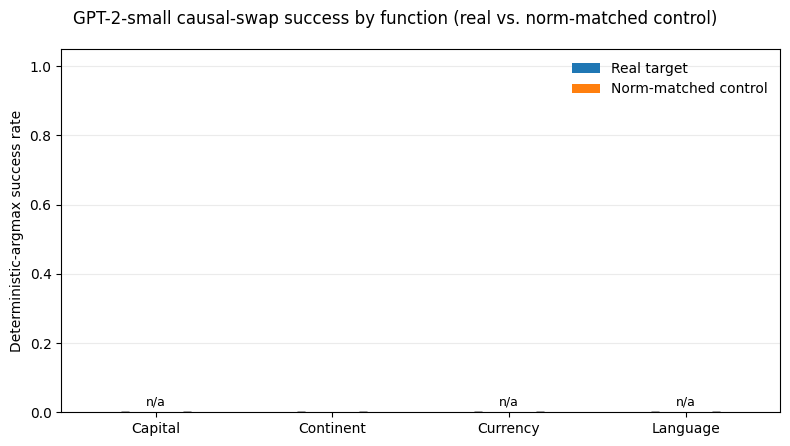

In [4]:
import matplotlib.pyplot as plt

plot_functions = [row["function"] for row in summary_rows if row["function"] != "overall"]
x = np.arange(len(plot_functions))
width = 0.35

real_values = []
real_errs = [[], []]
control_values = []
control_errs = [[], []]
has_data = []
for function in plot_functions:
    subset = ok_df[ok_df["function"] == function]
    if len(subset) == 0:
        has_data.append(False)
        real_values.append(0.0)
        control_values.append(0.0)
        real_errs[0].append(0.0)
        real_errs[1].append(0.0)
        control_errs[0].append(0.0)
        control_errs[1].append(0.0)
        continue
    has_data.append(True)
    real_ci = bootstrap_success_rate_ci(subset["real_success"].tolist())
    control_ci = bootstrap_success_rate_ci(subset["control_success"].tolist())
    real_values.append(real_ci.point_estimate)
    real_errs[0].append(real_ci.point_estimate - real_ci.ci_low)
    real_errs[1].append(real_ci.ci_high - real_ci.point_estimate)
    control_values.append(control_ci.point_estimate)
    control_errs[0].append(control_ci.point_estimate - control_ci.ci_low)
    control_errs[1].append(control_ci.ci_high - control_ci.point_estimate)

fig, ax = plt.subplots(figsize=(8, 4.5))
real_bars = ax.bar(
    x - width / 2, real_values, width, yerr=real_errs, capsize=3, label="Real target"
)
control_bars = ax.bar(
    x + width / 2, control_values, width, yerr=control_errs, capsize=3, label="Norm-matched control"
)
for i, present in enumerate(has_data):
    if not present:
        ax.annotate(
            "n/a", (x[i], 0.02), ha="center", fontsize=9, color="black"
        )
ax.set(
    ylabel="Deterministic-argmax success rate",
    xticks=x,
    xticklabels=[f.title() for f in plot_functions],
    ylim=(0, 1.05),
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.suptitle("GPT-2-small causal-swap success by function (real vs. norm-matched control)")
fig.tight_layout()
plt.show()

## Per-trial detail

Every trial that survived baseline filtering and had its source concept active in the
patched layer's support (`ok_trials` above). `control_token_id` is the raw vocabulary index
of the norm-matched control token; this notebook does not load a tokenizer, so it is not
decoded to text here.

In [5]:
detail_columns = [
    "function",
    "source",
    "target",
    "layer",
    "baseline_rank",
    "real_rank",
    "real_success",
    "control_token_id",
    "control_rank",
    "control_success",
]
ok_df[detail_columns].sort_values(["function", "layer", "source", "target"]).reset_index(drop=True)

,function,source,target,layer,baseline_rank,real_rank,real_success,control_token_id,control_rank,control_success
0,continent,Egypt,Canada,9,1,5,False,6918,5,False
1,continent,Egypt,China,9,1,4,False,1632,4,False
2,continent,Egypt,France,9,1,3,False,4771,3,False
3,continent,Egypt,Canada,10,1,5,False,4268,5,False
4,continent,Egypt,China,10,1,4,False,15185,4,False
5,continent,Egypt,France,10,1,3,False,12053,3,False


## Interpretation and caveats

- This is a **directional causal-effect** measurement under the stated controls, not proof of
  unique causal mediation: a successful swap shows the edit moved the output the predicted
  way relative to a norm-matched random edit, nothing stronger.
- Results are reported for **GPT-2-small only**; no claim is made about closed-weight models,
  and no claim about other open-weight models is implied.
- The corpus is the fixed reused country/function set; this is not an exhaustive-coverage
  claim over concepts or functions.
- Every trial is a **single-layer** intervention (one layer, the final prompt position). This
  says nothing about a multi-layer band protocol, which `coordinate_patch_hooks` was not
  designed for (stacking hooked layers is order-dependent and can raise).
- This notebook is independent of the existing `swap_hooks` country-swap benchmark elsewhere
  in this repository: different mechanism, different model, different protocol. Neither
  supersedes the other.